# SKA drift-scan results so far — summary

Three plots pulled from the two experiment notebooks in this directory:

- `ska_drift_scan.ipynb` — b ≈ +50°, off-plane baseline (experiments 001/002)
- `ska_drift_galplane.ipynb` — the same drift design swept across the galactic
  plane, plus a 1/f noise budget (experiment 003)

Both use an SKA-Mid-like 15 m dish at 350 MHz, 3 nights × 1 h parked drift at
el = 52/50/48°, identical noise seeds. This notebook only *reads* the numbers
those notebooks printed — re-run them first if you change anything.

In [1]:
# Load the results straight out of the two experiment notebooks — nothing is
# recomputed here, so this stays fast and always matches what those notebooks
# last printed.
import json
import re

import numpy as np
import matplotlib.pyplot as plt

NOTEBOOKS = {
    "b = +50 deg": "ska_drift_scan.ipynb",       # experiments 001/002
    "galactic plane": "ska_drift_galplane.ipynb",  # experiment 003
}

# Okabe-Ito, colourblind-safe, assigned by role.
C_NOHP, C_HP = "#0072B2", "#D55E00"
C_RECON, C_WHITE, C_1F = "#7F7F7F", "#0072B2", "#D55E00"


def notebook_text(path):
    nb = json.load(open(path))
    return "\n".join(
        "".join(o["text"])
        for c in nb["cells"] if c["cell_type"] == "code"
        for o in c.get("outputs", []) if o.get("output_type") == "stream"
    )


text = {reg: notebook_text(p) for reg, p in NOTEBOOKS.items()}

FILTERS = ["no HP", "HP 2 mHz"]
SCENARIOS = ["gauss", "airy", "mismatch"]

# residual RMS per scenario/filter, per regime
rms = {}
for reg, t in text.items():
    for sc, filt, val in re.findall(
            r"^(gauss|airy|mismatch)\s+(no HP|HP 2 mHz)\s+([\d.]+) mK", t, re.M):
        rms[(reg, sc, filt)] = float(val)

# map-space noise budget (printed by the 1/f study in the galplane notebook)
budget = {}
for reg, filt, tot, recon, white, onef, _q in re.findall(
        r"^(galactic plane|b = \+50 deg)\s+(no HP|HP 2 mHz)\s+"
        r"([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)",
        text["galactic plane"], re.M):
    budget[(reg, filt)] = dict(total=float(tot), recon=float(recon),
                               white=float(white), onef=float(onef))

# unmodelled-sidelobe map error (galactic plane)
sidelobe = {f: float(v) for f, v in re.findall(
    r"unmodelled-sidelobe map error \((no HP|HP 2 mHz)\): RMS =\s*([\d.]+) mK",
    text["galactic plane"], re.M)}

# Fail loudly rather than plot a half-parsed table.
assert len(rms) == 12, f"expected 12 residual-RMS entries, got {len(rms)}"
assert len(budget) == 4, f"expected 4 budget rows, got {len(budget)}"
assert len(sidelobe) == 2, f"expected 2 sidelobe rows, got {len(sidelobe)}"

for reg in NOTEBOOKS:
    for filt in FILTERS:
        print(f"{reg:16s} {filt:9s} " + "  ".join(
            f"{sc}={rms[(reg, sc, filt)]:8.1f} mK" for sc in SCENARIOS))

b = +50 deg      no HP     gauss=  1299.9 mK  airy=  1227.3 mK  mismatch=  1342.2 mK
b = +50 deg      HP 2 mHz  gauss=  1173.6 mK  airy=  1090.8 mK  mismatch=  1173.0 mK
galactic plane   no HP     gauss= 23081.4 mK  airy= 25262.0 mK  mismatch= 23901.2 mK
galactic plane   HP 2 mHz  gauss= 31439.3 mK  airy= 32206.9 mK  mismatch= 30668.1 mK


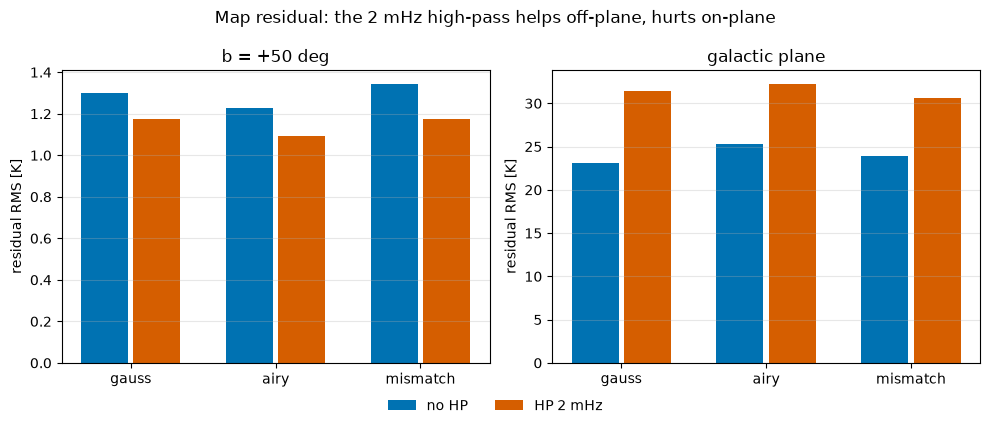

b = +50 deg      HP changes the gauss residual by -10%
galactic plane   HP changes the gauss residual by +36%


In [2]:
# 1. Residual RMS by scenario and filter. Separate panels because the two
#    regimes differ by ~20x — a shared axis would flatten the left one.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(len(SCENARIOS))
w = 0.36

for ax, reg in zip(axes, NOTEBOOKS):
    for j, (filt, col) in enumerate(zip(FILTERS, (C_NOHP, C_HP))):
        vals = [rms[(reg, sc, filt)] / 1e3 for sc in SCENARIOS]
        ax.bar(x + (j - 0.5) * w, vals, w * 0.9, color=col, label=filt)
    ax.set_xticks(x)
    ax.set_xticklabels(SCENARIOS)
    ax.set_ylabel("residual RMS [K]")
    ax.set_title(reg)
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Map residual: the 2 mHz high-pass helps off-plane, hurts on-plane")
fig.tight_layout()
h, lb = axes[0].get_legend_handles_labels()
fig.legend(h, lb, loc="lower center", ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.06))
fig.savefig("figures/summary_residual_rms.png", dpi=200, bbox_inches="tight")
plt.show()

for reg in NOTEBOOKS:
    a, b = rms[(reg, "gauss", "no HP")], rms[(reg, "gauss", "HP 2 mHz")]
    print(f"{reg:16s} HP changes the gauss residual by {(b - a) / a * 100:+.0f}%")

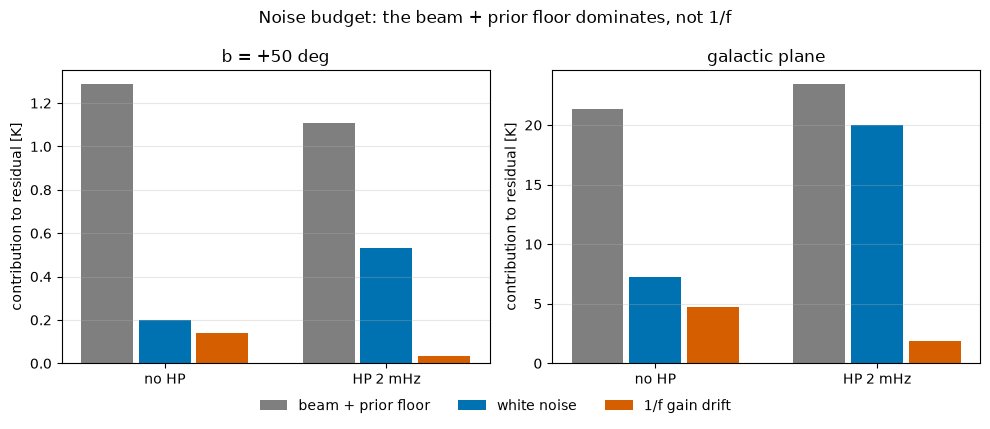

b = +50 deg      no HP: floor   1.29 K | white  0.20 K | 1/f  0.14 K -> total   1.30 K
galactic plane   no HP: floor  21.37 K | white  7.28 K | 1/f  4.77 K -> total  23.08 K


In [3]:
# 2. What actually limits the map: the residual split into the noiseless
#    beam + prior floor, the white-noise term and the 1/f term.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
comps = [("beam + prior floor", "recon", C_RECON),
         ("white noise", "white", C_WHITE),
         ("1/f gain drift", "onef", C_1F)]
x = np.arange(len(FILTERS))
w = 0.26

for ax, reg in zip(axes, NOTEBOOKS):
    for j, (lbl, key, col) in enumerate(comps):
        vals = [budget[(reg, f)][key] / 1e3 for f in FILTERS]
        ax.bar(x + (j - 1) * w, vals, w * 0.9, color=col, label=lbl)
    ax.set_xticks(x)
    ax.set_xticklabels(FILTERS)
    ax.set_ylabel("contribution to residual [K]")
    ax.set_title(reg)
    ax.grid(alpha=0.3, axis="y")

fig.suptitle("Noise budget: the beam + prior floor dominates, not 1/f")
fig.tight_layout()
h, lb = axes[0].get_legend_handles_labels()
fig.legend(h, lb, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.06))
fig.savefig("figures/summary_noise_budget.png", dpi=200, bbox_inches="tight")
plt.show()

for reg in NOTEBOOKS:
    b = budget[(reg, "no HP")]
    print(f"{reg:16s} no HP: floor {b['recon']/1e3:6.2f} K | "
          f"white {b['white']/1e3:5.2f} K | 1/f {b['onef']/1e3:5.2f} K "
          f"-> total {b['total']/1e3:6.2f} K")

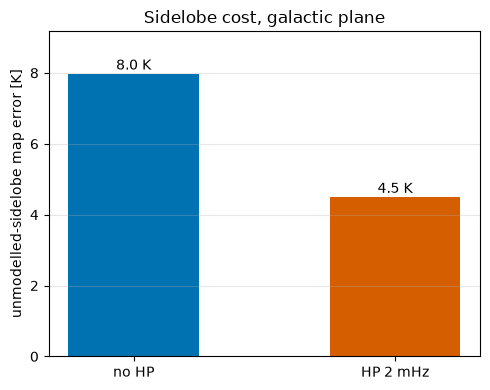

saved: figures/summary_residual_rms.png, summary_noise_budget.png, summary_sidelobe_cost.png


In [4]:
# 3. Cost of *unmodelled* sidelobes in the plane: the mismatch-minus-gauss map
#    difference, which shares the operator, mask, prior and noise realization,
#    so it isolates the sidelobe pickup. (At b = +50 deg this was ~3 mK, i.e.
#    off the bottom of this scale.)
fig, ax = plt.subplots(figsize=(5, 4))
vals = [sidelobe[f] / 1e3 for f in FILTERS]
ax.bar(FILTERS, vals, 0.5, color=[C_NOHP, C_HP])
for i, v in enumerate(vals):
    ax.annotate(f"{v:.1f} K", (i, v), textcoords="offset points",
                xytext=(0, 3), ha="center")
ax.set_ylabel("unmodelled-sidelobe map error [K]")
ax.set_ylim(0, max(vals) * 1.15)
ax.set_title("Sidelobe cost, galactic plane")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("figures/summary_sidelobe_cost.png", dpi=200, bbox_inches="tight")
plt.show()

print("saved: figures/summary_residual_rms.png, summary_noise_budget.png, "
      "summary_sidelobe_cost.png")

### Takeaways

1. Off-plane the 2 mHz high-pass is a mild win (−10%); across the plane it is a
   36% regression. It suppresses 1/f as intended, but at a 1-hour scan length
   2 mHz sits ~7× above the fundamental, so it also strips the sky's
   large-scale structure out of the operator and the white-noise term blows up.
2. The plane residual is dominated by the noiseless **beam + prior floor**
   (21.4 K of 23.1 K), not by 1/f (4.8 K). That floor is mostly sky the beam
   never measured, not a solver limit: a 3.99° beam over the patch gives ~15
   independent resolution elements while the nside=64 grid asks for 321
   parameters, and the residual is quoted against the unsmoothed truth
   (against the beam-smoothed truth it is 17.7 K). It responds to
   cross-linking, a tighter prior, or a beam-matched resolution — not to
   filtering or lower noise.
3. Unmodelled sidelobes cost ~8 K in the plane, against ~3 mK off-plane: the
   null result from experiment 002 does not survive contact with bright,
   structured emission.